In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/pinil/OneDrive/Escritorio/Analitica computacional/Proyecto/saber11_pregunta_3.csv")

In [3]:
df

,cole_depto_ubicacion,cole_mcpio_ubicacion,estu_depto_presentacion,estu_depto_reside,fami_tienecomputador,fami_tieneinternet,punt_matematicas,punt_lectura_critica,punt_ingles,punt_c_naturales,punt_sociales_ciudadanas,punt_global,grupo_tec
0,SANTANDER,VELEZ,SANTANDER,SANTANDER,Si,No,33.0,23.0,45.0,36.0,38.0,167.0,Solo computador
1,SANTANDER,CAPITANEJO,SANTANDER,SANTANDER,Si,No,83.0,59.0,52.0,69.0,60.0,333.0,Solo computador
2,SANTANDER,BUCARAMANGA,SANTANDER,SANTANDER,Si,Si,65.0,59.0,60.0,63.0,65.0,314.0,Computador + internet
3,SANTANDER,BUCARAMANGA,SANTANDER,SANTANDER,Si,Si,65.0,59.0,60.0,63.0,65.0,314.0,Computador + internet
4,SANTANDER,BUCARAMANGA,SANTANDER,SANTANDER,No,No,50.0,63.0,55.0,61.0,63.0,295.0,Sin acceso
...,...,...,...,...,...,...,...,...,...,...,...,...,...
198877,SANTANDER,SUCRE,SANTANDER,SANTANDER,No,No,58.0,57.0,55.0,54.0,50.0,274.0,Sin acceso
198878,SANTANDER,FLORIDABLANCA,SANTANDER,SANTANDER,Si,Si,54.0,44.0,49.0,50.0,44.0,240.0,Computador + internet
198879,SANTANDER,FLORIDABLANCA,SANTANDER,SANTANDER,Si,Si,54.0,44.0,49.0,50.0,44.0,240.0,Computador + internet
198880,SANTANDER,BUCARAMANGA,SANTANDER,SANTANDER,Si,Si,67.0,66.0,74.0,68.0,66.0,337.0,Computador + internet


Distribucion de puntajes por acceso tecnologico

C:\Users\pinil\AppData\Local\Temp\ipykernel_12560\2203864594.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


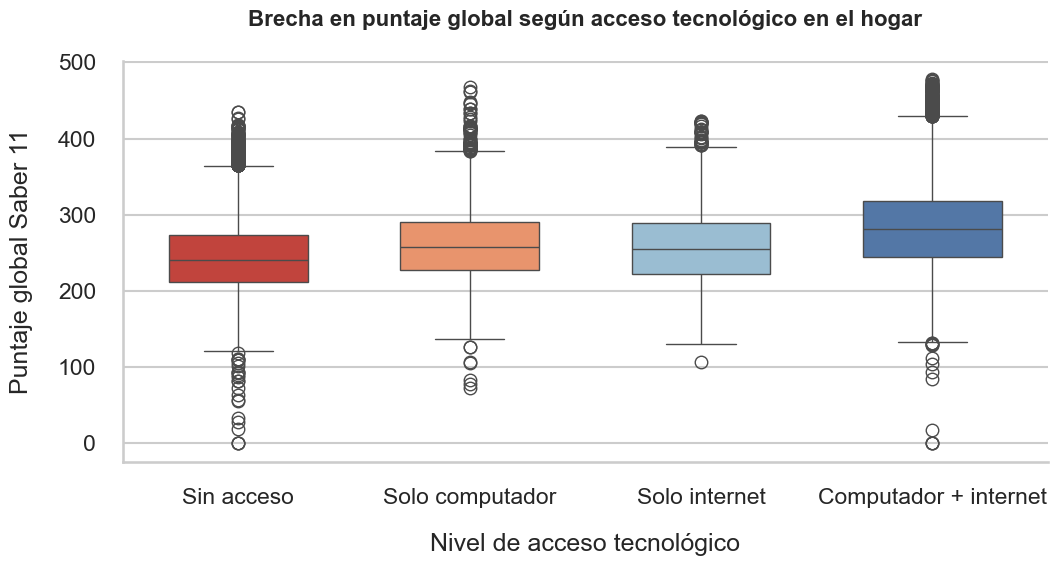

In [4]:
# estilo general
sns.set_theme(style="whitegrid", context="talk")

# orden lógico
orden = [
    "Sin acceso",
    "Solo computador",
    "Solo internet",
    "Computador + internet"
]

# paleta consistente
palette = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

plt.figure(figsize=(11,6))

ax = sns.boxplot(
    data=df,
    x="grupo_tec",
    y="punt_global",
    order=orden,
    palette=palette,
    width=0.6,
    showfliers=True   # ← mantener valores extremos
)

# título
plt.title(
    "Brecha en puntaje global según acceso tecnológico en el hogar",
    fontsize=16,
    weight="bold",
    pad=25   # separación del título
)

# etiquetas con mayor distancia
plt.xlabel(
    "Nivel de acceso tecnológico",
    labelpad=18   # distancia eje X
)

plt.ylabel(
    "Puntaje global Saber 11",
    labelpad=18   # distancia eje Y
)

# separación etiquetas del eje
plt.tick_params(axis='x', pad=10)
plt.tick_params(axis='y', pad=10)

sns.despine()

plt.tight_layout()
plt.show()

In [5]:
# Promedio de puntaje global por grupo tecnológico
promedios = (
    df.groupby("grupo_tec")["punt_global"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print("Puntaje promedio por acceso tecnológico:")
print(promedios)

Puntaje promedio por acceso tecnológico:
grupo_tec
Computador + internet    281.93
Solo computador          259.63
Solo internet            256.50
Sin acceso               244.01
Name: punt_global, dtype: float64


Grafico de areas academicas segun grupo tecnologico

C:\Users\pinil\AppData\Local\Temp\ipykernel_12560\565675628.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres_areas, rotation=0)  # horizontal


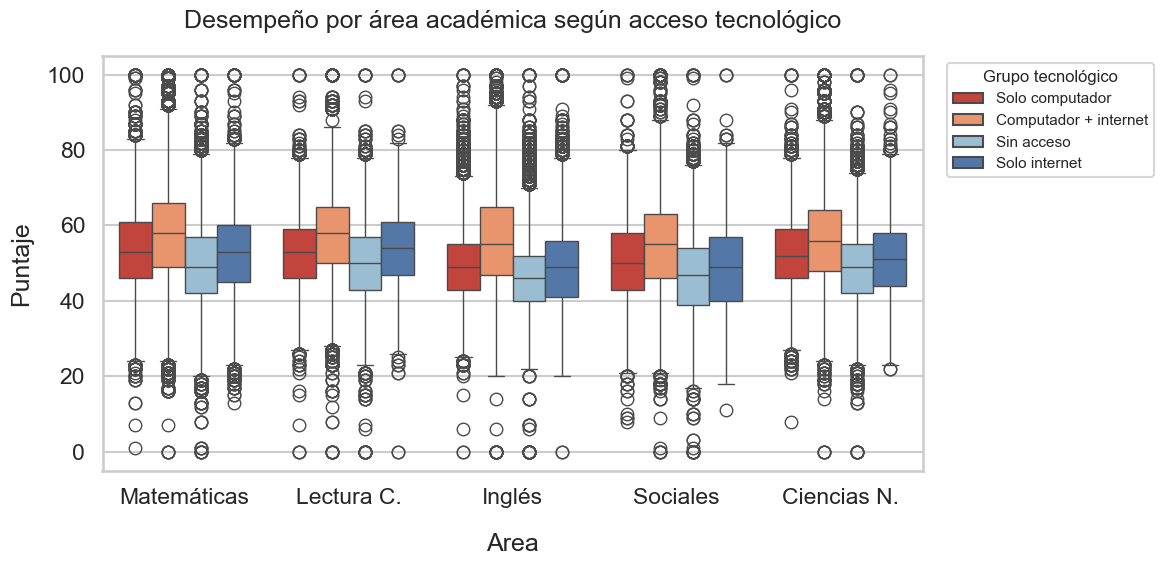

In [6]:
areas = [
    "punt_matematicas",
    "punt_lectura_critica",
    "punt_ingles",
    "punt_sociales_ciudadanas",
    "punt_c_naturales"
]

df_melt = df.melt(
    id_vars="grupo_tec",
    value_vars=areas,
    var_name="Area",
    value_name="Puntaje"
)

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df_melt,
    x="Area",
    y="Puntaje",
    hue="grupo_tec",
    palette=palette
)


nombres_areas = [
    "Matemáticas",
    "Lectura C.",
    "Inglés",
    "Sociales",
    "Ciencias N."
]

ax.set_xticklabels(nombres_areas, rotation=0)  # horizontal


plt.title("Desempeño por área académica según acceso tecnológico",
          fontsize=18,
          pad=20)
ax.set_ylabel("Puntaje", labelpad=10)
ax.set_xlabel("Area",labelpad=18)

plt.legend(
    title="Grupo tecnológico",
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11
)

plt.tight_layout()
plt.show()

Grafico 15 municipios con mas estudiantes segun Grupo tecnologico

In [7]:
top_municipios = (
    df["cole_mcpio_ubicacion"]
    .value_counts()
    .head(15)
    .index
)

df_top = df[df["cole_mcpio_ubicacion"].isin(top_municipios)]

In [8]:
municipio_tec_2= (
    df_top.groupby(["cole_mcpio_ubicacion","grupo_tec"])["punt_global"]
    .mean()
    .reset_index()
)

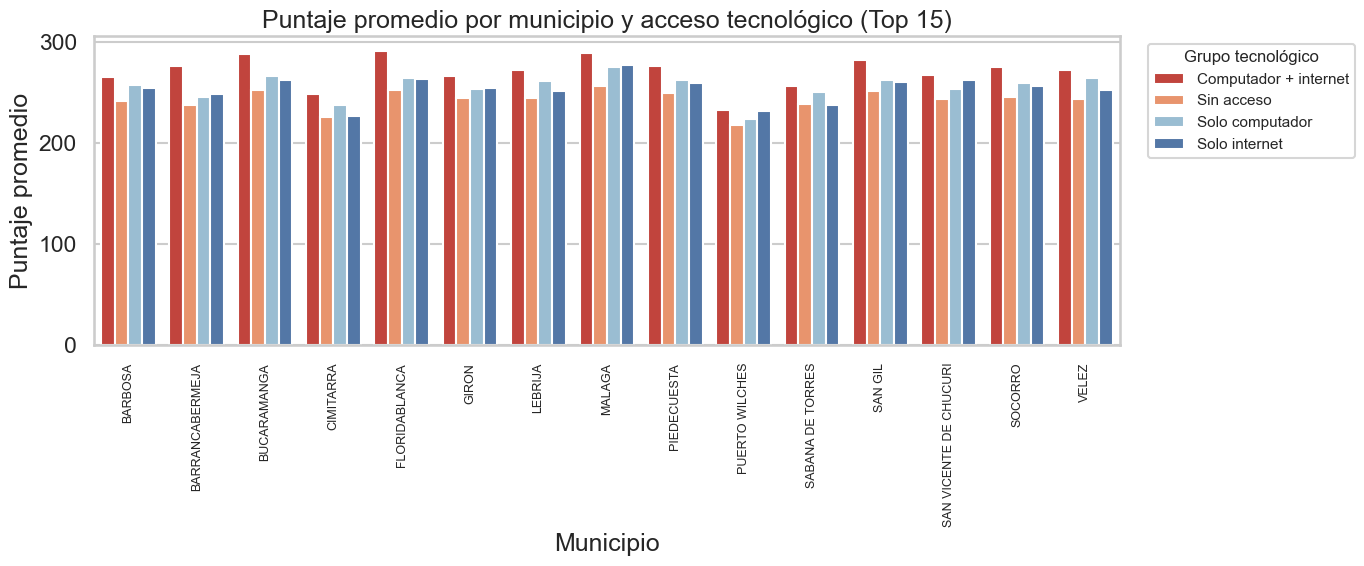

In [9]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=municipio_tec_2,
    x="cole_mcpio_ubicacion",
    y="punt_global",
    hue="grupo_tec",
    palette=palette
)
plt.xticks(rotation=90,fontsize=9)  # etiquetas verticales

plt.title("Puntaje promedio por municipio y acceso tecnológico (Top 15)")
plt.xlabel("Municipio")
plt.ylabel("Puntaje promedio")

plt.legend(
    title="Grupo tecnológico",
    title_fontsize=12,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11
)

plt.tight_layout()
plt.show()

Heat map segun municipio para cada grupo tecnologico

In [10]:
municipio_tec_1 = (
    df.groupby(["cole_mcpio_ubicacion", "grupo_tec"])["punt_global"]
    .mean()
    .reset_index()
)

tabla_heat = municipio_tec_1.pivot(
    index="cole_mcpio_ubicacion",
    columns="grupo_tec",
    values="punt_global"
)

# ordenar municipios por promedio total
orden = tabla_heat.mean(axis=1).sort_values(ascending=False).index
tabla_heat = tabla_heat.loc[orden]

n_municipios = len(tabla_heat)

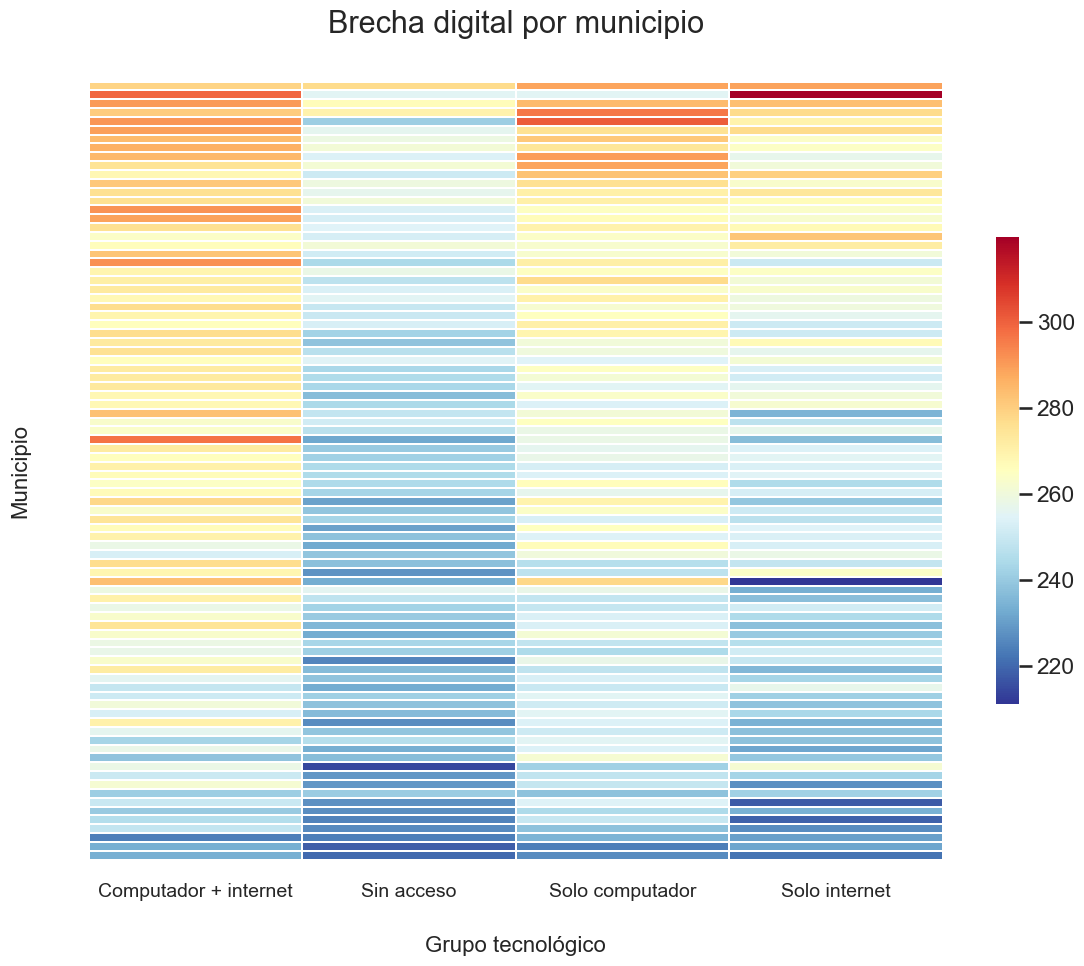

In [11]:
plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    tabla_heat,
    cmap="RdYlBu_r",
    annot=False,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"shrink": 0.6}
)

# ---- TITULO PRINCIPAL ----
ax.set_title(
    "Brecha digital por municipio",
    fontsize=22,
    pad=35
)

# ---- EJE X ----
ax.set_xlabel(
    "Grupo tecnológico",
    fontsize=16,
    labelpad=25
)

# ---- EJE Y ----
ax.set_ylabel(
    "Municipio",
    fontsize=16,
    labelpad=30
)

# quitar nombres municipios
ax.set_yticklabels([])

# tamaño etiquetas eje X
ax.tick_params(axis="x", labelsize=14, pad=8)

plt.tight_layout()
plt.show()